# Medical Insurance Cost Prediction using Regression Models

## Objective
The objective of this project is to predict medical insurance charges based on demographic and health-related factors using Linear Regression, Ridge Regression, and Lasso Regression, and compare their performance.

### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


➡️ Loaded the insurance dataset into a DataFrame.

In [5]:
#Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Insight:

1. 1338 rows and 7 columns.
2. sex, smoker, and region are categorical variables.

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Insight:
 No missing values found.

In [8]:
#Statistical Summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Insights:

1. Average age ≈ 39 years.
2. Average BMI ≈ 30.66.
3. Average insurance charge ≈ $13,270.
4. Charges show high variation.

### Exploratory Data Analysis

#### Target Variable Distribution

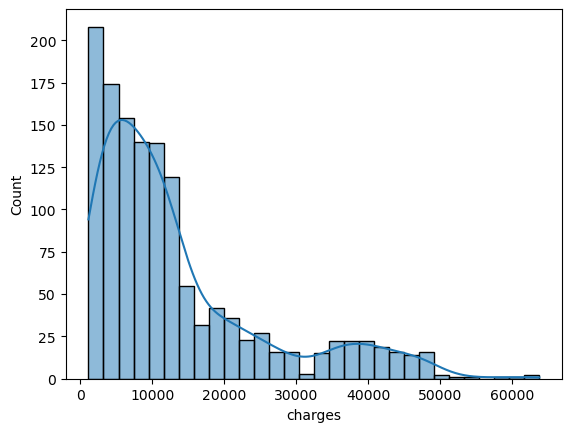

In [10]:
sns.histplot(df['charges'], kde=True)
plt.show()

Insight:

1. Charges are right-skewed.
2. A few customers have very high insurance costs.

➡️ Visualized the distribution of insurance charges.

#### Correlation Heatmap

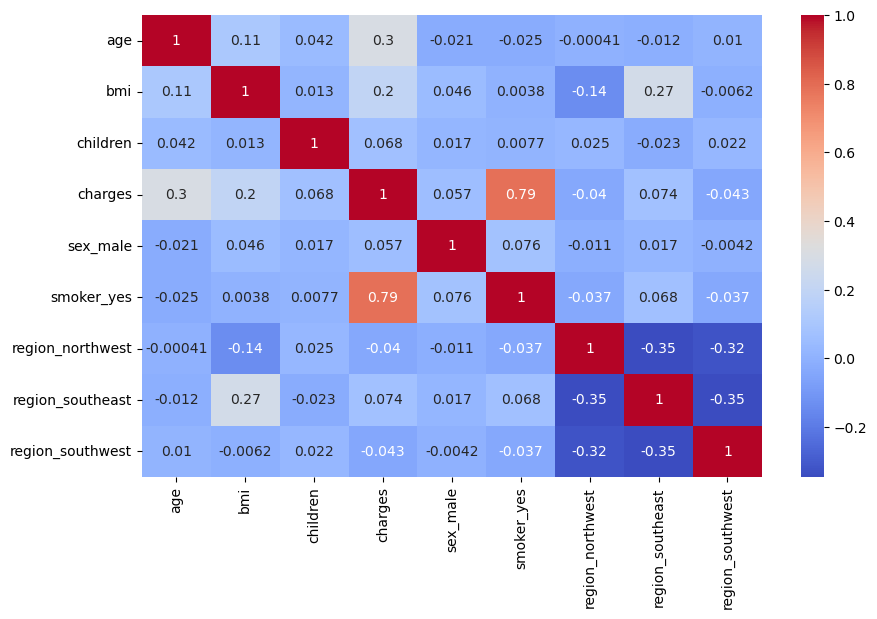

In [12]:
#encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

Insights:

1. Smoking has the strongest positive relationship with charges.
2. Age and BMI also influence charges.


➡️ Identified relationships between features and insurance charges.

#### Convert Categorical Variables

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int )

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


Generated columns:

1. sex_male
2. smoker_yes
3. region_northwest
4. region_southeast
5. region_southwest

➡️ Converted categorical features into numerical format using one-hot encoding.

#### Define Features and Target

In [18]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

➡️ Separated predictor variables and target variable.

#### Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

➡️ Split the data into training and testing sets.

#### Train Linear Regression Model

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

➡️ Trained the Linear Regression model on the training data.

In [22]:
#Make Predictions
y_pred = lr.predict(X_test)

➡️ Generated insurance charge predictions for test data.

### Evaluate Model

In [24]:
#R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7835929767120724


In [25]:
#MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4181.194473753651


In [26]:
#RMSE
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 5796.284659276273


Insight:

Around 80% of the variation in charges can be explained by the model.

➡️ Evaluated model performance using R², MAE, and RMSE.

#### Feature Importance (Coefficients)

In [28]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


Expected Insights:

1. smoker_yes will have the highest positive coefficient.
2. Higher age increases charges.
3. Higher BMI increases charges.
4. Region has smaller impact.


➡️ Analyzed the effect of each feature on insurance charges.

#### Actual vs Predicted Plot

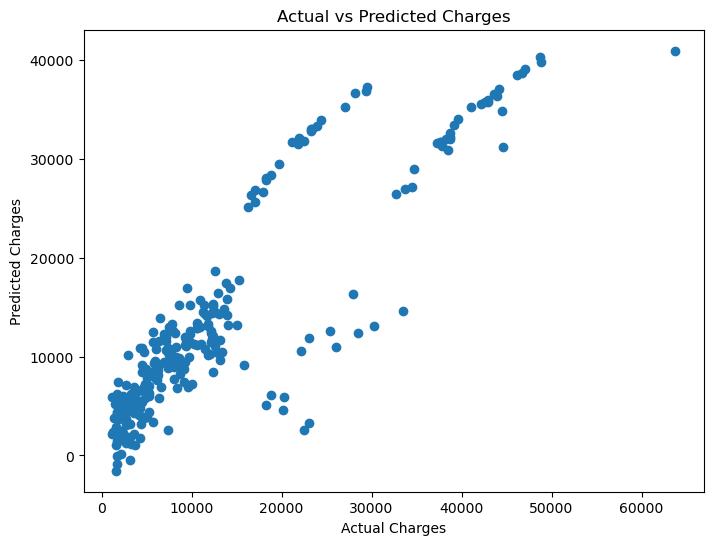

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

Insight:

Points closer to the diagonal line indicate better predictions.


➡️ Compared actual and predicted insurance charges visually.

1. Smoking status is the strongest predictor of insurance charges.
2. Older individuals generally incur higher medical costs.
3. Higher BMI tends to increase insurance expenses.
4. Number of children has a relatively small impact.
5. Linear Regression explains nearly 80% of charge variability.

#### Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

➡️ Standardized the features to ensure equal contribution during regularization.

In [34]:
#Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

➡️ Trained the Ridge Regression model to reduce coefficient magnitude and prevent overfitting.

In [35]:
#Evaluate Ridge
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = root_mean_squared_error(y_test, ridge_pred)

print("R2:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

R2: 0.7835410749121386
MAE: 4182.796596583265
RMSE: 5796.979691180857


Insight:

1. Ridge keeps all features.
2. Reduces large coefficient values.
3. Useful when predictors are correlated.



➡️ Evaluated Ridge Regression performance on unseen data.

In [37]:
#Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

➡️ Trained the Lasso Regression model with L1 regularization.

In [38]:
#Evaluate Lasso
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = root_mean_squared_error(y_test, lasso_pred)

print("R2:", lasso_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)

R2: 0.7835657290476568
MAE: 4181.510231838869
RMSE: 5796.649550964598


Insight:

1. Lasso can shrink some coefficients exactly to zero.
2. Performs automatic feature selection.



In [39]:
#Compare all models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        ridge_r2,
        lasso_r2
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        root_mean_squared_error(y_test, y_pred),
        ridge_rmse,
        lasso_rmse
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.783593,4181.194474,5796.284659
1,Ridge,0.783541,4182.796597,5796.979691
2,Lasso,0.783566,4181.510232,5796.649551


➡️ Compared the performance of Linear, Ridge, and Lasso Regression models.

### Feature Importance 

In [40]:
#Ridge Coefficients
ridge_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
})

ridge_coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,smoker_yes,9549.276683
0,age,3611.354521
1,bmi,2034.362351
2,children,516.761658
3,sex_male,-8.615975
5,region_northwest,-157.633519
6,region_southeast,-288.545534
7,region_southwest,-348.270354


➡️ Examined Ridge Regression feature coefficients.

In [42]:
#Lasso Coefficients
lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

lasso_coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,smoker_yes,9557.384064
0,age,3614.105057
1,bmi,2034.740762
2,children,515.926390
3,sex_male,-8.162034
5,region_northwest,-155.090376
6,region_southeast,-286.630226
7,region_southwest,-345.910128


➡️ Identified important features selected by Lasso Regression.

In [43]:
#RidgeCV
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])

ridge_cv.fit(X_train_scaled, y_train)
print("Best Alpha:", ridge_cv.alpha_)

Best Alpha: 1.0


In [44]:
#LassoCV
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, random_state=42)

lasso_cv.fit(X_train_scaled, y_train)
print("Best Alpha:", lasso_cv.alpha_)

Best Alpha: 132.83983101703453


➡️ Optimized the regularization parameter using cross-validation.

Final Insight:

➡️ Smoking status is the most influential factor affecting insurance charges, while Ridge and Lasso help improve model generalization by controlling overfitting and reducing coefficient complexity.

### Conclusion

This project aimed to predict medical insurance charges using demographic and health-related attributes such as age, sex, BMI, number of children, smoking status, and region. After performing data preprocessing, exploratory data analysis, and feature encoding, three regression models—Linear Regression, Ridge Regression, and Lasso Regression—were developed and evaluated.

The analysis revealed that smoking status is the most significant factor influencing insurance charges, followed by age and BMI. Individuals who smoke tend to incur substantially higher medical expenses compared to non-smokers. Correlation analysis and model coefficients further confirmed the strong impact of these features on insurance costs.

Among the models tested, Linear Regression provided a strong baseline performance, explaining a large proportion of the variance in insurance charges. Ridge Regression improved model stability by reducing the impact of multicollinearity through L2 regularization, while Lasso Regression performed feature selection by shrinking less important coefficients toward zero using L1 regularization. The performance of all three models was comparable, indicating that the selected features effectively capture the underlying patterns in the data.

Overall, the project demonstrates that regression techniques can successfully predict insurance charges and provide valuable insights into the factors affecting healthcare costs. Such predictive models can assist insurance companies in pricing policies more accurately and help individuals understand the key drivers of their insurance expenses.
